# Autonomous Decision Engine

This script:
- Combines anomaly scores and RUL predictions
- Computes a unified RISK SCORE (0-100)
- Maps risk to autonomous decisions (continue, alert or shutdown)
- Generates a full decision log with confidence levels
- Produces final evaluation plots

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')

In [5]:
import os
os.chdir(r"C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\spacecraft-anomaly-detection")
print(os.getcwd())

C:\Users\hibro\OneDrive\Desktop\Desktop_Files\Projects\Python\ML_Models\Deep_Space_Anomaly_Detection\spacecraft-anomaly-detection


# Data Loading

Loading anomaly scores and RUL Predictions

In [6]:

# Anomaly results (having scores for all engines)
anomaly_df = pd.read_csv('data/anomaly_results.csv')
 
# RUL predictions (only test engines)
rul_df = pd.read_csv('data/rul_predictions.csv')
 
print(f"Anomaly data: {len(anomaly_df)} rows")
print(f"RUL predictions: {len(rul_df)} rows")
print(f"Columns in anomaly_df: {anomaly_df.columns.tolist()}")

Anomaly data: 20631 rows
RUL predictions: 3711 rows
Columns in anomaly_df: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'RUL_clipped', 'anomaly_label', 'iso_forest_score', 'svm_score', 'autoencoder_score', 'iso_forest_pred', 'svm_pred', 'autoencoder_pred']


# Risk Scoring System

The risk score combines two signals:
1. Anomaly score [how abnormal is the current reading?] (0-1)
2. Predicted RUL [how much life is left?] (0-125)

 Formula:
   risk = w1 * normalized_anomaly + w2 * (1 - normalized_rul)

Low RUL = High risk, High Anomaly = High risk

 Final risk is scaled 0-100

In [7]:

# Function for computing risk score:
def compute_risk_score(anomaly_scores, rul_values,
                       anomaly_weight=0.4, rul_weight=0.6):
    """
    Parameters:
        anomaly_scores: higher = more anomalous (any range)
        rul_values: remaining useful life (0-125)
        anomaly_weight: importance of anomaly signal (0.4 = 40%)
        rul_weight: importance of RUL signal (0.6 = 60%)
    
    Returns:
        risk_scores: array of values 0-100
    """

    # Normalize (z-score) anomaly scores to 0-1 range
    a_min, a_max = anomaly_scores.min(), anomaly_scores.max()
    if a_max > a_min:
        norm_anomaly = (anomaly_scores - a_min) / (a_max - a_min)
    else:
        norm_anomaly = np.zeros_like(anomaly_scores)
    
    # Normalize RUL to 0-1 (invert: low RUL = high risk)
    max_rul = 125.0
    norm_rul_risk = 1.0 - np.clip(rul_values, 0, max_rul) / max_rul
    
    # Weighted combination
    risk = anomaly_weight * norm_anomaly + rul_weight * norm_rul_risk
    
    # Scale to 0-100
    return (risk * 100).clip(0, 100)
 
 


In [8]:
# Compute risk scores using the anomaly data (all engines)
# Using Isolation Forest scores as they performed the best
risk_scores = compute_risk_score(
    anomaly_scores=anomaly_df['iso_forest_score'].values,
    rul_values=anomaly_df['RUL'].values
)
 
anomaly_df['risk_score'] = risk_scores
 
print(f"Risk score range: {risk_scores.min():.1f} to {risk_scores.max():.1f}")
print(f"Mean risk: {risk_scores.mean():.1f}")
print(f"Median risk: {np.median(risk_scores):.1f}")

Risk score range: 0.3 to 99.9
Mean risk: 33.0
Median risk: 20.3


# Decision Logic Engine

This is the Rule-Based Engine that would run onboard the spacecraft.
Based on the risk score, it recommends an action.

- Risk 0-30:   NOMINAL    → Continue normal operations
- Risk 30-60:  CAUTION    → Increase monitoring frequency
- Risk 60-80:  WARNING    → Alert ground station, prepare backup
- Risk 80-100: CRITICAL   → Shut down subsystem / switch to redundancy

In [9]:


def classify_risk(risk_score):
    # Map risk score to decision category.
    if risk_score < 30:
        return 'NOMINAL'
    elif risk_score < 60:
        return 'CAUTION'
    elif risk_score < 80:
        return 'WARNING'
    else:
        return 'CRITICAL'
 
def get_action(risk_level):
    #Map risk level to recommended autonomous action
    actions = {
        'NOMINAL':  'Continue normal operations',
        'CAUTION':  'Increase monitoring frequency to 2x',
        'WARNING':  'Alert ground station, prepare backup subsystem',
        'CRITICAL': 'Shut down subsystem, switch to redundancy'
    }
    return actions[risk_level]
 
def get_confidence(risk_score):
    """
    Decision confidence (how certain is the system about this recommendation?)
    Scores near the thresholds (30, 60, 80) have lower confidence.
    """
    thresholds = [30, 60, 80]
    min_dist = min(abs(risk_score - t) for t in thresholds)
    # Further from threshold = higher confidence
    confidence = min(min_dist / 15.0, 1.0)  # normalize to 0-1
    return round(confidence * 100, 1)
 
# Apply to all data
anomaly_df['risk_level'] = anomaly_df['risk_score'].apply(classify_risk)
anomaly_df['action'] = anomaly_df['risk_level'].apply(get_action)
anomaly_df['confidence'] = anomaly_df['risk_score'].apply(get_confidence)
 
# Summary
level_counts = anomaly_df['risk_level'].value_counts()
print("\nDecision Distribution:")
for level in ['NOMINAL', 'CAUTION', 'WARNING', 'CRITICAL']:
    count = level_counts.get(level, 0)
    pct = count / len(anomaly_df) * 100
    action = get_action(level)
    print(f"  {level:10s}: {count:6d} ({pct:5.1f}%) → {action}")


Decision Distribution:
  NOMINAL   :  12083 ( 58.6%) → Continue normal operations
  CAUTION   :   4035 ( 19.6%) → Increase monitoring frequency to 2x
  CRITICAL  :   2349 ( 11.4%) → Shut down subsystem, switch to redundancy


# Decision Log for Sample Engines

In [15]:

# Decision log for engines 1, 3, 5, 10, 20, 25, 50, 75, 99 and 100 (last 60 cycles before failure)


for eng_id in [1, 3, 5, 10, 20, 25, 50, 75, 99, 100]:
    engine_data = anomaly_df[anomaly_df['engine_id'] == eng_id].tail(60)
    print(f"\nEngine #{eng_id} — Last 60 cycles before failure:")
    print("-" * 90)
    print(f"{'Cycle':>6} {'RUL':>5} {'Anomaly':>10} {'Risk':>6} {'Level':>10} {'Confidence':>11}  Action")
    print("-" * 90)
    for _, row in engine_data.iterrows():
        print(f"{row['cycle']:6.0f} {row['RUL']:5.0f} "
              f"{row['iso_forest_score']:10.4f} "
              f"{row['risk_score']:6.1f} "
              f"{row['risk_level']:>10s} "
              f"{row['confidence']:10.1f}%  "
              f"{row['action']}")
    print()


Engine #1 — Last 60 cycles before failure:
------------------------------------------------------------------------------------------
 Cycle   RUL    Anomaly   Risk      Level  Confidence  Action
------------------------------------------------------------------------------------------
   133    59    -0.0321   39.4    CAUTION       62.7%  Increase monitoring frequency to 2x
   134    58    -0.0177   41.5    CAUTION       76.7%  Increase monitoring frequency to 2x
   135    57    -0.0434   39.1    CAUTION       60.7%  Increase monitoring frequency to 2x
   136    56     0.0152   46.1    CAUTION       92.4%  Increase monitoring frequency to 2x
   137    55     0.0093   46.0    CAUTION       93.6%  Increase monitoring frequency to 2x
   138    54    -0.0336   41.6    CAUTION       77.6%  Increase monitoring frequency to 2x
   139    53     0.0257   48.8    CAUTION       75.0%  Increase monitoring frequency to 2x
   140    52    -0.0301   43.0    CAUTION       86.6%  Increase monitoring 

# Evaluation Plots

In [16]:
# Color mapping for risk levels
risk_colors = {
    'NOMINAL': '#639922',   # green
    'CAUTION': '#EF9F27',   # amber
    'WARNING': '#D85A30',   # coral/orange
    'CRITICAL': '#E24B4A'   # red
}

## Risk Score over Engine Lifetime

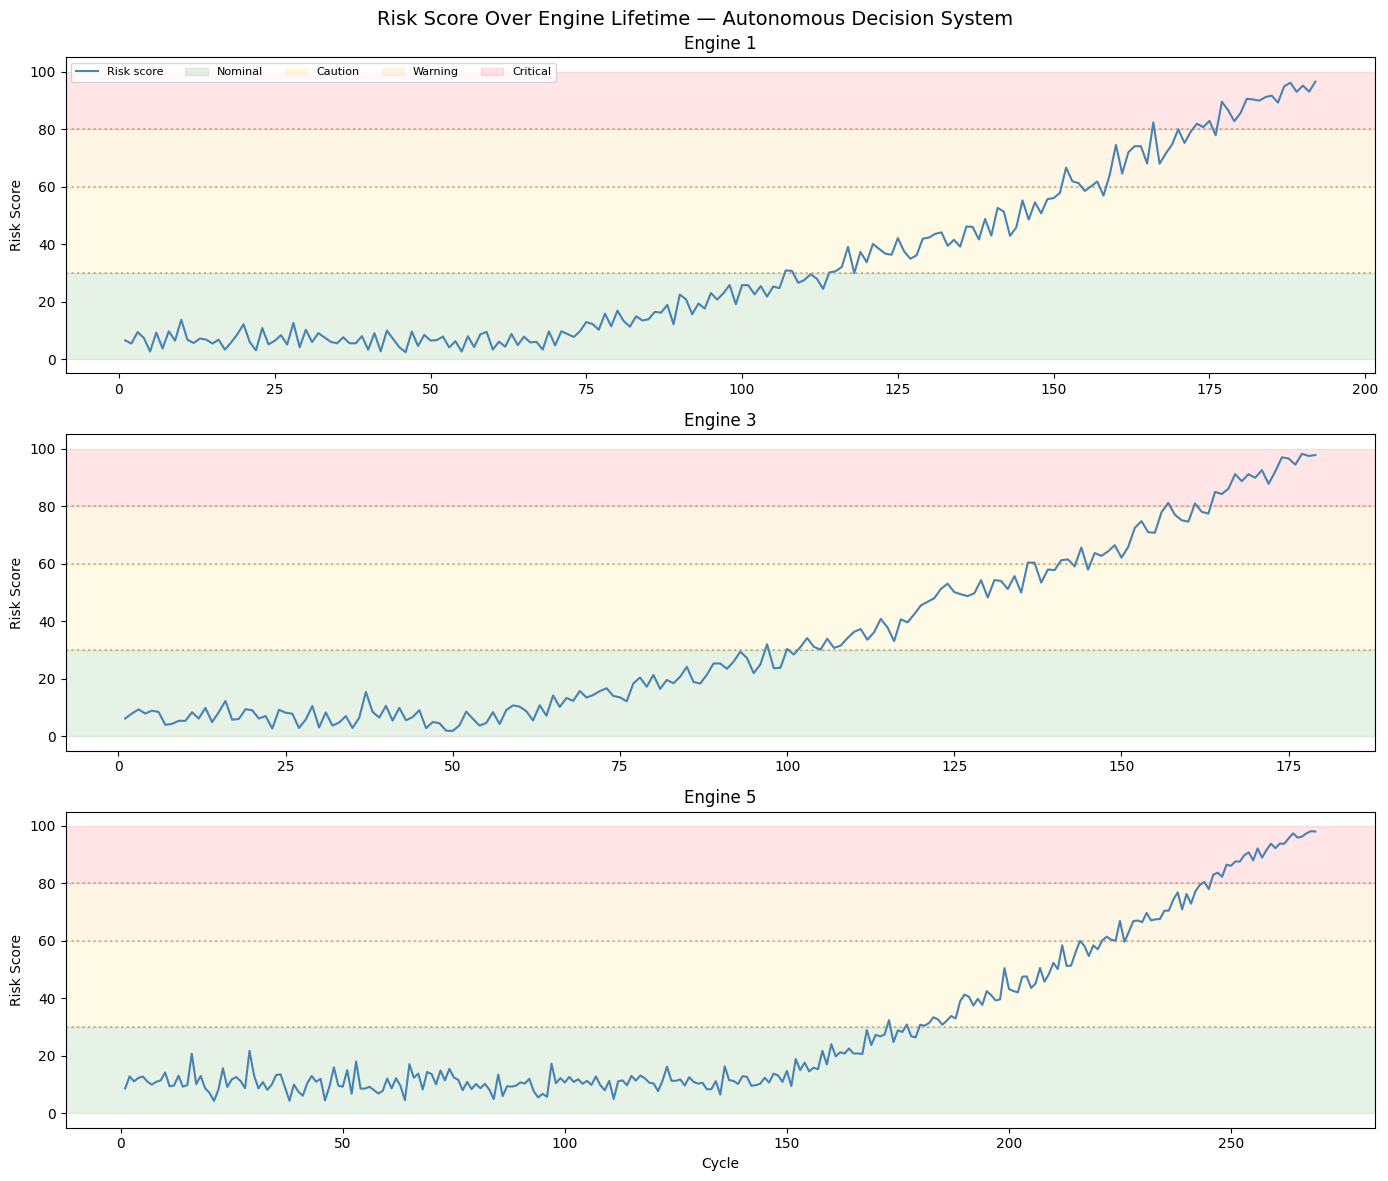

Saved: results/risk_score_timeline.png


In [ ]:
# for Sample Engines 1, 3 and 5

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Risk Score Over Engine Lifetime — Autonomous Decision System', fontsize=14)
 
sample_engines = [1, 3, 5]
for idx, eng_id in enumerate(sample_engines):
    ax = axes[idx]
    eng_data = anomaly_df[anomaly_df['engine_id'] == eng_id]
    
    # Plot risk score line
    ax.plot(eng_data['cycle'], eng_data['risk_score'],
            color='steelblue', linewidth=1.5, label='Risk score')
    
    # Color background by risk zone
    ax.axhspan(0, 30, alpha=0.1, color='green', label='Nominal')
    ax.axhspan(30, 60, alpha=0.1, color='gold', label='Caution')
    ax.axhspan(60, 80, alpha=0.1, color='orange', label='Warning')
    ax.axhspan(80, 100, alpha=0.1, color='red', label='Critical')
    
    # Threshold lines
    for thresh in [30, 60, 80]:
        ax.axhline(y=thresh, color='gray', linestyle=':', alpha=0.5)
    
    ax.set_ylabel('Risk Score')
    ax.set_title(f'Engine {eng_id}')
    ax.set_ylim(-5, 105)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=8, ncol=5)
    if idx == 2:
        ax.set_xlabel('Cycle')
 
plt.tight_layout()
plt.savefig('results/risk_score_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/risk_score_timeline.png")

## Decision Distribution

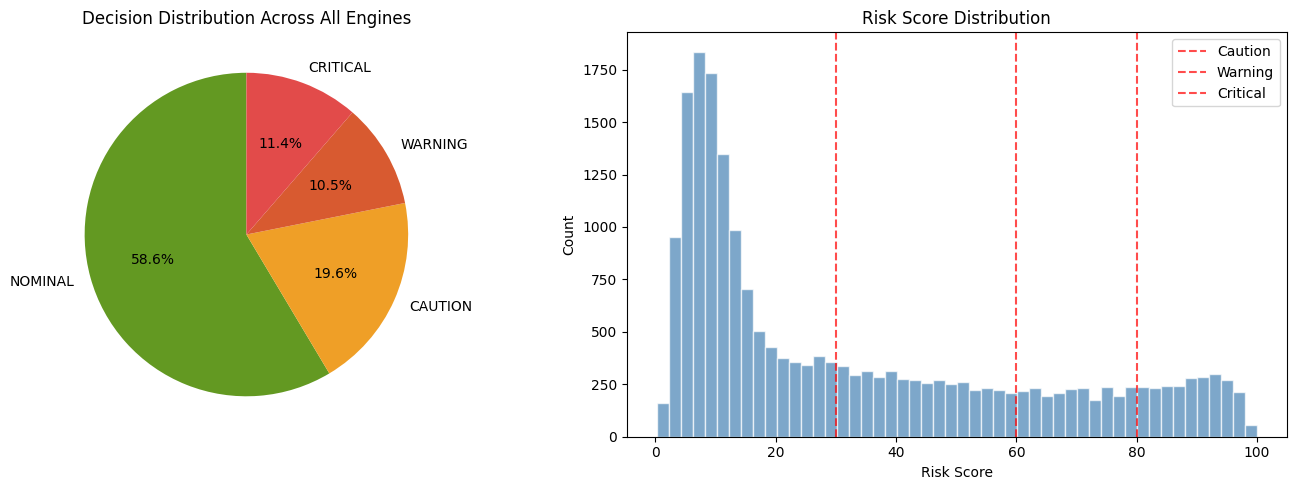

Saved: results/decision_distribution.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Pie chart
labels = ['NOMINAL', 'CAUTION', 'WARNING', 'CRITICAL']
sizes = [level_counts.get(l, 0) for l in labels]
colors_pie = [risk_colors[l] for l in labels]
 
axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Decision Distribution Across All Engines')
 
# Risk score histogram
axes[1].hist(anomaly_df['risk_score'], bins=50, color='steelblue',
             alpha=0.7, edgecolor='white')
for thresh, label in [(30, 'Caution'), (60, 'Warning'), (80, 'Critical')]:
    axes[1].axvline(x=thresh, color='red', linestyle='--', alpha=0.7, label=label)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Risk Score Distribution')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('results/decision_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/decision_distribution.png")

## Risk Score VS Actual RUL

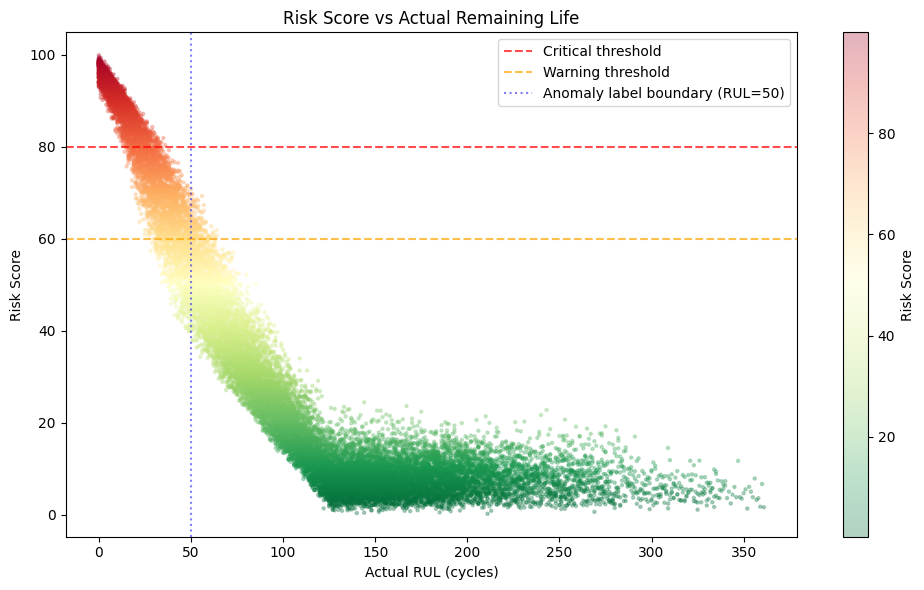

Saved: results/risk_vs_rul.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
 
# Scatter Plot
scatter = ax.scatter(anomaly_df['RUL'], anomaly_df['risk_score'],
                     c=anomaly_df['risk_score'], cmap='RdYlGn_r',
                     alpha=0.3, s=5)
ax.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Critical threshold')
ax.axhline(y=60, color='orange', linestyle='--', alpha=0.7, label='Warning threshold')
ax.axvline(x=50, color='blue', linestyle=':', alpha=0.5,
           label='Anomaly label boundary (RUL=50)')
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Risk Score')
ax.set_title('Risk Score vs Actual Remaining Life')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Risk Score')
plt.tight_layout()
plt.savefig('results/risk_vs_rul.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/risk_vs_rul.png")

## Precision-Recall Curve

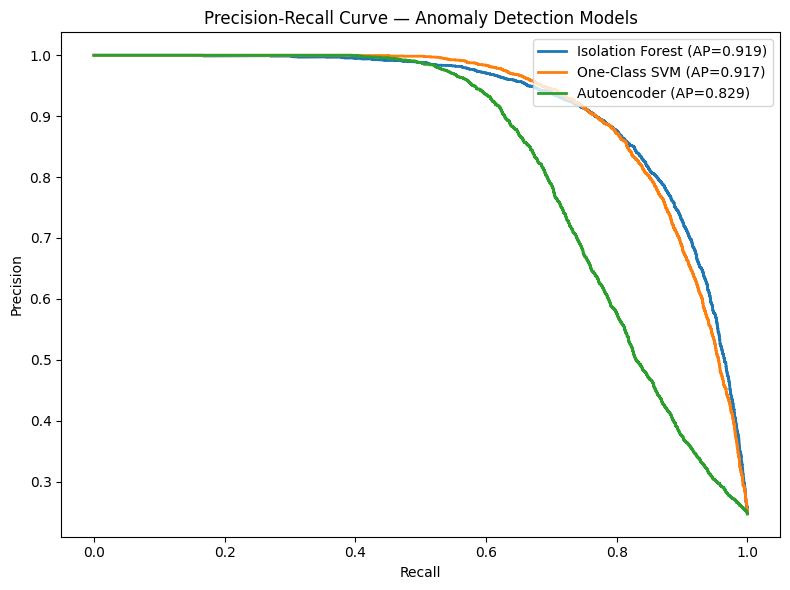

Saved: results/precision_recall_curve.png


In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
 
y_true = anomaly_df['anomaly_label'].values
 
for score_col, name in [('iso_forest_score', 'Isolation Forest'),
                         ('svm_score', 'One-Class SVM'),
                         ('autoencoder_score', 'Autoencoder')]:
    precision, recall, _ = precision_recall_curve(y_true, anomaly_df[score_col])
    ap = average_precision_score(y_true, anomaly_df[score_col])
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)
 
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Anomaly Detection Models')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('results/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/precision_recall_curve.png")


## Confusion Matrix

'CRITICAL' and 'WARNING' treated as Anomaly Detected

'NOMINAL' and 'CAUTION' treated as Normal

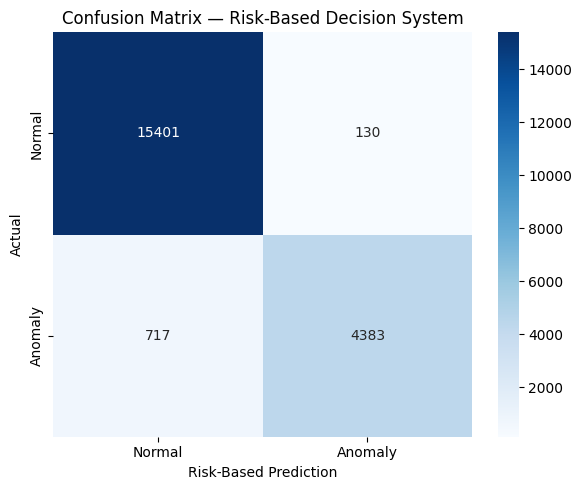

Saved: results/risk_confusion_matrix.png


In [23]:
risk_pred = (anomaly_df['risk_level'].isin(['WARNING', 'CRITICAL'])).astype(int)
 
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, risk_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_xlabel('Risk-Based Prediction')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Risk-Based Decision System')
plt.tight_layout()
plt.savefig('results/risk_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/risk_confusion_matrix.png")

# Saving Decision Log

In [25]:
# Save complete decision log
decision_cols = ['engine_id', 'cycle', 'RUL', 'iso_forest_score',
                 'risk_score', 'risk_level', 'action', 'confidence']
decision_log = anomaly_df[decision_cols].copy()
decision_log.to_csv('data/decision_log.csv', index=False)
print("Saved: data/decision_log.csv")


Saved: data/decision_log.csv


# Summary

In [26]:
# Final summary
 
print(f"""
ANOMALY DETECTION:
  Isolation Forest:  {roc_auc_score(y_true, anomaly_df['iso_forest_score']):.3f} ROC-AUC
  One-Class SVM:     {roc_auc_score(y_true, anomaly_df['svm_score']):.3f} ROC-AUC
  Autoencoder:       {roc_auc_score(y_true, anomaly_df['autoencoder_score']):.3f} ROC-AUC
 
RUL PREDICTION:
  RMSE: 15.25 cycles  |  MAE: 12.26 cycles  |  R²: 0.8671
 
DECISION ENGINE:
  Risk scoring: Anomaly (40%) + RUL (60%) weighted combination
  Decision levels: NOMINAL | CAUTION | WARNING | CRITICAL
  Total decisions logged: {len(decision_log)}
""")
 
# Classification report for the risk-based system
print("Risk-Based Detection Performance:")
print(classification_report(y_true, risk_pred,
                            target_names=['Normal', 'Anomaly']))


ANOMALY DETECTION:
  Isolation Forest:  0.959 ROC-AUC
  One-Class SVM:     0.954 ROC-AUC
  Autoencoder:       0.879 ROC-AUC
 
RUL PREDICTION:
  RMSE: 15.25 cycles  |  MAE: 12.26 cycles  |  R²: 0.8671
 
DECISION ENGINE:
  Risk scoring: Anomaly (40%) + RUL (60%) weighted combination
  Decision levels: NOMINAL | CAUTION | WARNING | CRITICAL
  Total decisions logged: 20631

Risk-Based Detection Performance:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.97     15531
     Anomaly       0.97      0.86      0.91      5100

    accuracy                           0.96     20631
   macro avg       0.96      0.93      0.94     20631
weighted avg       0.96      0.96      0.96     20631

